# Testing Folder Flow: Full Body -> Gaussian per Part -> Injury/Not

This notebook runs exactly in this order on images from `testing/`:

1. Show **full body keypoints** for each image (YOLOv8-pose).
2. Create and show **Gaussian masks for each body part** (`right_arm`, `left_arm`, `right_leg`, `left_leg`).
3. Run CLIP (and optional LoRA) on each masked part and report **injured / not injured**.

In [1]:
import sys
import subprocess

# OpenCV repair for environments that fail with libavcodec errors.
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "uninstall",
        "-y",
        "opencv-python",
        "opencv-contrib-python",
        "opencv-python-headless",
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "opencv-python-headless==4.8.1.78"], check=True)

deps = [
    "numpy<2.0", "torch", "matplotlib", "ultralytics", "Pillow", "pandas",
    "ftfy", "regex", "certifi"
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *deps], check=True)
print("Setup complete:", sys.executable)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ultralytics 8.4.41 requires opencv-python>=4.6.0, which is not installed.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.4 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.4 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.4.4 which is incompatible.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 5.29.5 which is incompatible.
numba 0.59.1 requires numpy<1.27,>=1.22, but you have numpy 2.4.4 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.4.4 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.32.0 requir

Setup complete: /opt/anaconda3/bin/python


In [2]:
from pathlib import Path
import os
import importlib

import certifi
import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

from pose_gaussian_only import calculate_sigma, apply_gaussian_splatting_image

PROJECT_ROOT = Path.cwd()
TESTING_DIR = PROJECT_ROOT / "testing"
RESULTS_DIR = PROJECT_ROOT / "Results" / "notebook_testing_flow"
PART_MASK_DIR = RESULTS_DIR / "part_masks"
PART_MASK_DIR.mkdir(parents=True, exist_ok=True)

POSE_MODEL_NAME = "yolov8n-pose.pt"
POSE_MODEL = YOLO(POSE_MODEL_NAME)

KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow", "left_wrist", "right_wrist",
    "left_hip", "right_hip", "left_knee", "right_knee", "left_ankle", "right_ankle"
]

BODY_PARTS = {
    "right_arm": [6, 8, 10],
    "left_arm": [5, 7, 9],
    "right_leg": [12, 14, 16],
    "left_leg": [11, 13, 15],
}

image_paths = [TESTING_DIR / "002.png"]
if not image_paths[0].exists():
    raise RuntimeError(f"Missing target image: {image_paths[0]}")

print("Testing folder:", TESTING_DIR)
print("Using image:", image_paths[0].name)
print("Output dir:", RESULTS_DIR)

Testing folder: /Users/kushgarg/Desktop/Programs/cv_project/testing
Using image: 002.png
Output dir: /Users/kushgarg/Desktop/Programs/cv_project/Results/notebook_testing_flow


## 1) Full body keypoints + Gaussian mask for each part

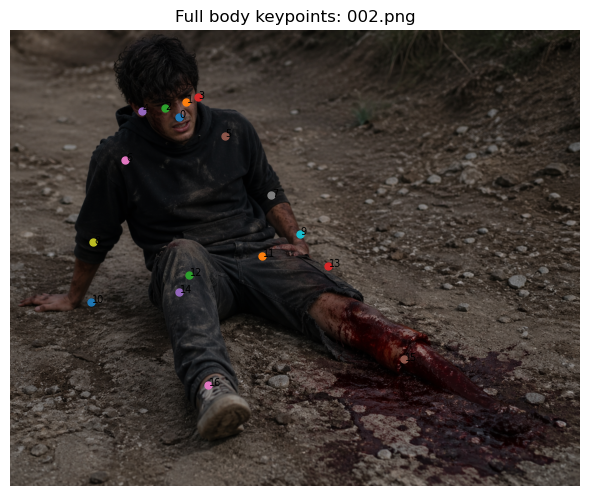

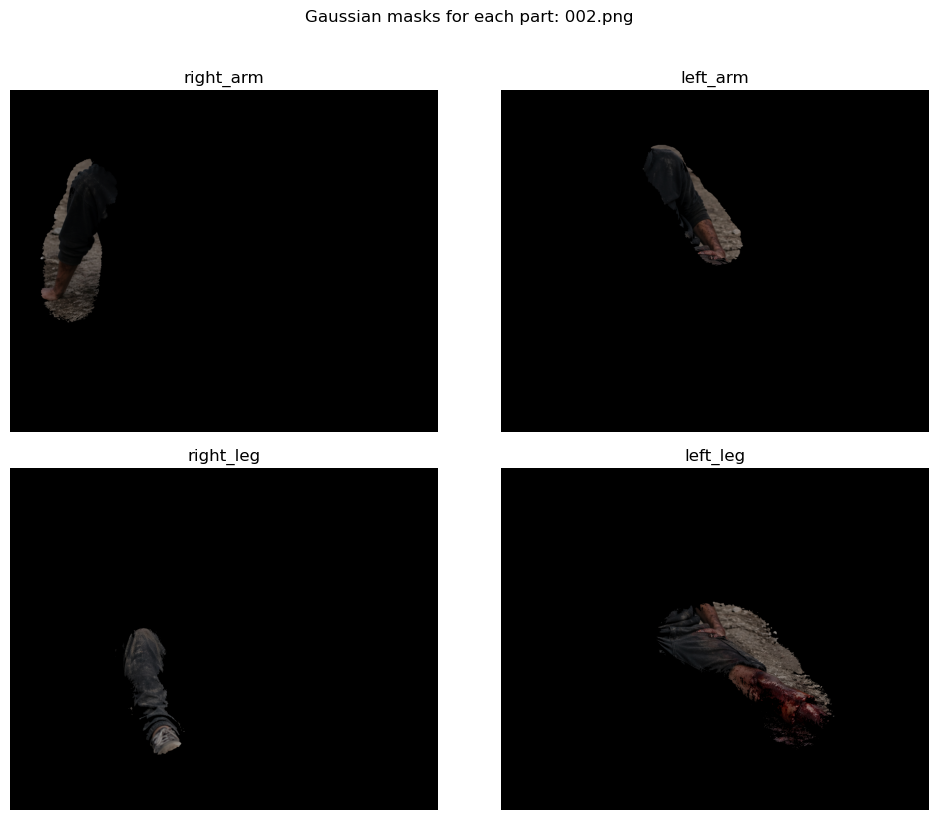

,image,status,detected_keypoints
0,002.png,ok,17


,image,part,mask_path,sigma_1,sigma_2
0,002.png,right_arm,/Users/kushgarg/Desktop/Programs/cv_project/Re...,32.620,21.918
1,002.png,left_arm,/Users/kushgarg/Desktop/Programs/cv_project/Re...,27.878,17.612
2,002.png,right_leg,/Users/kushgarg/Desktop/Programs/cv_project/Re...,7.332,36.008
3,002.png,left_leg,/Users/kushgarg/Desktop/Programs/cv_project/Re...,24.588,44.253


In [3]:
pose_rows = []
part_rows = []

for img_path in image_paths:
    image_bgr = cv2.imread(str(img_path))
    if image_bgr is None:
        pose_rows.append({"image": img_path.name, "status": "read-failed"})
        continue

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    results = POSE_MODEL.predict(str(img_path), conf=0.4, verbose=False)

    if not results or results[0].keypoints is None or results[0].keypoints.xy is None or results[0].keypoints.xy.numel() == 0:
        pose_rows.append({"image": img_path.name, "status": "no-person-detected"})
        continue

    person_kpts = results[0].keypoints.xy[0].cpu().numpy()

    # --- Show full body keypoints ---
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(image_rgb)
    for idx, (x, y) in enumerate(person_kpts):
        ax.scatter([x], [y], s=25)
        ax.text(x + 2, y + 2, str(idx), fontsize=7)
    ax.set_title(f"Full body keypoints: {img_path.name}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    pose_rows.append({"image": img_path.name, "status": "ok", "detected_keypoints": len(person_kpts)})

    # --- Build Gaussian output for each body part ---
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()
    for ax_idx, (part_name, part_indices) in enumerate(BODY_PARTS.items()):
        points = [(int(person_kpts[i][0]), int(person_kpts[i][1])) for i in part_indices]
        sigmas = [calculate_sigma(points[i], points[i + 1]) for i in range(len(points) - 1)]
        splatted = apply_gaussian_splatting_image(image_bgr, points, sigmas)
        mask = cv2.inRange(splatted, np.array([1, 1, 1]), np.array([255, 255, 255]))
        masked = cv2.bitwise_and(image_bgr, image_bgr, mask=mask)

        out_path = PART_MASK_DIR / f"{img_path.stem}_{part_name}.jpg"
        cv2.imwrite(str(out_path), masked)

        axes[ax_idx].imshow(cv2.cvtColor(masked, cv2.COLOR_BGR2RGB))
        axes[ax_idx].set_title(f"{part_name}")
        axes[ax_idx].axis("off")

        part_rows.append(
            {
                "image": img_path.name,
                "part": part_name,
                "mask_path": str(out_path),
                "sigma_1": round(float(sigmas[0]), 3),
                "sigma_2": round(float(sigmas[1]), 3),
            }
        )

    plt.suptitle(f"Gaussian masks for each part: {img_path.name}", y=1.02)
    plt.tight_layout()
    plt.show()

pose_df = pd.DataFrame(pose_rows)
part_df = pd.DataFrame(part_rows)
display(pose_df)
display(part_df.head(20))

## 2) CLIP/LoRA: injury or not for each part, and final image-level decision

In [4]:
CLIP_LORA_DIR = PROJECT_ROOT / "CLIP-LoRA"
if str(CLIP_LORA_DIR) not in sys.path:
    sys.path.insert(0, str(CLIP_LORA_DIR))

clip = importlib.import_module("clip")
loralib_utils = importlib.import_module("loralib.utils")

CLASS_NAMES = ["injury", "no_injury", "injury_and_amputation"]
PROMPT_TEMPLATES = [
    "For the highlighted limb {} is present.",
    "The limb condition is {}.",
    "This limb shows {}.",
]
INJURY_SCORE_THRESHOLD = 0.38

os.environ["SSL_CERT_FILE"] = certifi.where()
device = "cuda" if torch.cuda.is_available() else "cpu"

def build_text_features(clip_model, prompt_templates):
    class_embeddings = []
    with torch.no_grad():
        for class_name in CLASS_NAMES:
            prompts = [template.format(class_name.replace("_", " ")) for template in prompt_templates]
            tokens = clip.tokenize(prompts).to(device)
            prompt_features = clip_model.encode_text(tokens)
            prompt_features = prompt_features / prompt_features.norm(dim=-1, keepdim=True)
            class_feature = prompt_features.mean(dim=0)
            class_feature = class_feature / class_feature.norm()
            class_embeddings.append(class_feature)
    return torch.stack(class_embeddings, dim=0)

def predict_probs_with_features(image_path: Path, clip_model, preprocess, text_features):
    img = Image.open(image_path).convert("RGB")
    t = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = clip_model.encode_image(t)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        logits = 100.0 * image_features @ text_features.t()
        probs = torch.softmax(logits, dim=-1).squeeze(0)
    return probs.detach().cpu().numpy()

def combine_probs(probs_clip, probs_lora):
    probs_combined = (probs_clip + probs_lora) / 2.0
    pred_idx = int(np.argmax(probs_combined))
    pred_class = CLASS_NAMES[pred_idx]
    injury_idx = CLASS_NAMES.index("injury")
    no_injury_idx = CLASS_NAMES.index("no_injury")
    amp_idx = CLASS_NAMES.index("injury_and_amputation")
    injury_score = float(probs_combined[injury_idx] + probs_combined[amp_idx])
    no_injury_prob = float(probs_combined[no_injury_idx])
    pred_binary = "injury" if injury_score >= INJURY_SCORE_THRESHOLD else "no_injury"
    return {
        "predicted_class": pred_class,
        "pred_binary": pred_binary,
        "injury_prob": float(probs_combined[injury_idx]),
        "no_injury_prob": no_injury_prob,
        "injury_and_amputation_prob": float(probs_combined[amp_idx]),
        "injury_score": injury_score,
        "clip_injury_score": float(probs_clip[injury_idx] + probs_clip[amp_idx]),
        "lora_injury_score": float(probs_lora[injury_idx] + probs_lora[amp_idx]),
    }

# Build CLIP-only model
try:
    clip_model_base, preprocess_base = clip.load("ViT-B/16", device=device)
except Exception as e:
    if "CERTIFICATE_VERIFY_FAILED" in str(e):
        os.environ["PYTHONHTTPSVERIFY"] = "0"
        clip_model_base, preprocess_base = clip.load("ViT-B/16", device=device)
    else:
        raise
clip_model_base.eval()
text_features_base = build_text_features(clip_model_base, PROMPT_TEMPLATES)

# Build CLIP+LoRA model
clip_model_lora, preprocess_lora = clip.load("ViT-B/16", device=device)
clip_model_lora.eval()
lora_ckpt = CLIP_LORA_DIR / "weights" / "lora_weights_960_2.9566854533582632e-05.pt"
if not lora_ckpt.exists():
    raise RuntimeError(f"LoRA checkpoint missing: {lora_ckpt}")

from types import SimpleNamespace
args = SimpleNamespace(
    backbone="ViT-B/16", dataset="tromnet", shots=16, seed=1,
    position="all", encoder="both", params=["q", "k", "v"],
    r=2, alpha=1, dropout_rate=0.25,
    save_path=str(lora_ckpt), filename="lora_weights"
)
lora_layers = loralib_utils.apply_lora(args, clip_model_lora)
loralib_utils.load_lora(args, lora_layers)
text_features_lora = build_text_features(clip_model_lora, PROMPT_TEMPLATES)

def predict_probs(image_path: Path):
    probs_clip = predict_probs_with_features(image_path, clip_model_base, preprocess_base, text_features_base)
    probs_lora = predict_probs_with_features(image_path, clip_model_lora, preprocess_lora, text_features_lora)
    return combine_probs(probs_clip, probs_lora)

print("Device:", device)
print("Prompt templates:", PROMPT_TEMPLATES)
print("LoRA:", "loaded")

Residual Attention Block 0: ResidualAttentionBlock(
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (ln_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (mlp): Sequential(
    (c_fc): Linear(in_features=512, out_features=2048, bias=True)
    (gelu): QuickGELU()
    (c_proj): Linear(in_features=2048, out_features=512, bias=True)
  )
  (ln_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)
Residual Attention Block 1: ResidualAttentionBlock(
  (attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (ln_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (mlp): Sequential(
    (c_fc): Linear(in_features=512, out_features=2048, bias=True)
    (gelu): QuickGELU()
    (c_proj): Linear(in_features=2048, out_features=512, bias=True)
  )
  (ln_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
)
Residual Atten

In [5]:
if part_df.empty:
    raise RuntimeError("No part masks were generated. Check pose step output.")

pred_rows = []
for _, r in part_df.iterrows():
    pred = predict_probs(Path(r["mask_path"]))
    pred_rows.append(
        {
            "image": r["image"],
            "part": r["part"],
            "predicted_class": pred["predicted_class"],
            "injured_or_not": pred["pred_binary"],
            "injury_prob": round(pred["injury_prob"], 4),
            "no_injury_prob": round(pred["no_injury_prob"], 4),
            "injury_and_amputation_prob": round(pred["injury_and_amputation_prob"], 4),
            "injury_score": round(pred["injury_score"], 4),
            "clip_injury_score": round(pred["clip_injury_score"], 4),
            "lora_injury_score": round(pred["lora_injury_score"], 4),
            "mask_path": r["mask_path"],
        }
    )

pred_df = pd.DataFrame(pred_rows)
display(pred_df)

# Image-level decision: if ANY part is injury, mark image as injury.
image_level = pred_df.groupby("image").apply(
    lambda g: pd.Series(
        {
            "image_injured_or_not": "injury" if (g["injured_or_not"] == "injury").any() else "no_injury",
            "max_injury_score": round(float(g["injury_score"].max()), 4),
        }
    )
).reset_index()

display(image_level)

,image,part,predicted_class,injured_or_not,injury_prob,no_injury_prob,injury_and_amputation_prob,mask_path
0,002.png,right_arm,no_injury,no_injury,0.0000,1.0000,0.0000,/Users/kushgarg/Desktop/Programs/cv_project/Re...
1,002.png,left_arm,no_injury,no_injury,0.0000,1.0000,0.0000,/Users/kushgarg/Desktop/Programs/cv_project/Re...
2,002.png,right_leg,no_injury,no_injury,0.0000,1.0000,0.0000,/Users/kushgarg/Desktop/Programs/cv_project/Re...
3,002.png,left_leg,no_injury,no_injury,0.0008,0.9976,0.0016,/Users/kushgarg/Desktop/Programs/cv_project/Re...


/var/folders/zb/l7t2wv8s1r1dnmf0v6c2wjlm0000gp/T/ipykernel_95774/2587647814.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  image_level = pred_df.groupby("image").apply(


,image,image_injured_or_not,max_injury_prob
0,002.png,no_injury,0.0008
